In [1]:
# ============================================================
# Transformer Architecture – End-to-End Lab (PyTorch)
# ============================================================

import math, random, re
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
import torch # High-level pytorch library
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [2]:
!nvidia-smi

Fri Jan 30 19:12:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(7)
random.seed(7)


device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# ============================================================
# 1️- Raw Text Input
# ============================================================
# raw_text = "Transformers changed AI. Transformers are cool!"
# raw_text = "I want to go to the store to purchase somethings."
raw_text = "Artificial intelligence systems learn by identifying patterns in data and refining their internal representations through optimization. In natural language processing, models are trained on large corpora of text to capture syntax, semantics, and contextual relationships between words. During training, the model predicts missing or future tokens and adjusts its parameters to minimize prediction error. Over time, this process enables the system to generalize beyond memorized examples, allowing it to answer questions, generate coherent text, summarize information, and reason across domains. The effectiveness of such models depends on data quality, architectural design, training objectives, and careful evaluation to ensure robustness, fairness, and reliability."
print("1) Raw text:", raw_text)

1) Raw text: Artificial intelligence systems learn by identifying patterns in data and refining their internal representations through optimization. In natural language processing, models are trained on large corpora of text to capture syntax, semantics, and contextual relationships between words. During training, the model predicts missing or future tokens and adjusts its parameters to minimize prediction error. Over time, this process enables the system to generalize beyond memorized examples, allowing it to answer questions, generate coherent text, summarize information, and reason across domains. The effectiveness of such models depends on data quality, architectural design, training objectives, and careful evaluation to ensure robustness, fairness, and reliability.


In [5]:
# ============================================================
# 2️- Text Normalization (Tokenizer Preprocessing)
# ============================================================

def normalize_text(text: str, lower: bool = False) -> str:
    # normalization: Unicode-ish cleanup, whitespace normalization

    text = text.replace("\u00A0", " ")            # non-breaking spaces

    text = re.sub(r"\s+", " ", text).strip()      # normalize whitespace

    if lower:
        text = text.lower()
    return text

norm_text = normalize_text(raw_text, lower=False)
print("2) Normalized text:", norm_text)

# Special tokens (common in real systems)
BOS, EOS, PAD, UNK = "<BOS>", "<EOS>", "<PAD>", "<UNK>"

2) Normalized text: Artificial intelligence systems learn by identifying patterns in data and refining their internal representations through optimization. In natural language processing, models are trained on large corpora of text to capture syntax, semantics, and contextual relationships between words. During training, the model predicts missing or future tokens and adjusts its parameters to minimize prediction error. Over time, this process enables the system to generalize beyond memorized examples, allowing it to answer questions, generate coherent text, summarize information, and reason across domains. The effectiveness of such models depends on data quality, architectural design, training objectives, and careful evaluation to ensure robustness, fairness, and reliability.


In [6]:
# ============================================================
# 3️- Text → Tokens (Tokenization)
# ============================================================

def toy_subword_tokenize(text: str) -> List[str]:
    # split into words and punctuation
    parts = re.findall(r"[A-Za-z]+|[0-9]+|[^\w\s]", text)

    tokens = [] # Empty list

    for p in parts:
        if p.isalpha() and len(p) > 6:
            # pretend subword: first 6 chars + "##rest"
            tokens.append(p[:6])
            tokens.append("##" + p[6:])
        else:
            tokens.append(p)
    return tokens

tokens = [BOS] + toy_subword_tokenize(norm_text) + [EOS]
print("3) Tokens:", tokens)

3) Tokens: ['<BOS>', 'Artifi', '##cial', 'intell', '##igence', 'system', '##s', 'learn', 'by', 'identi', '##fying', 'patter', '##ns', 'in', 'data', 'and', 'refini', '##ng', 'their', 'intern', '##al', 'repres', '##entations', 'throug', '##h', 'optimi', '##zation', '.', 'In', 'natura', '##l', 'langua', '##ge', 'proces', '##sing', ',', 'models', 'are', 'traine', '##d', 'on', 'large', 'corpor', '##a', 'of', 'text', 'to', 'captur', '##e', 'syntax', ',', 'semant', '##ics', ',', 'and', 'contex', '##tual', 'relati', '##onships', 'betwee', '##n', 'words', '.', 'During', 'traini', '##ng', ',', 'the', 'model', 'predic', '##ts', 'missin', '##g', 'or', 'future', 'tokens', 'and', 'adjust', '##s', 'its', 'parame', '##ters', 'to', 'minimi', '##ze', 'predic', '##tion', 'error', '.', 'Over', 'time', ',', 'this', 'proces', '##s', 'enable', '##s', 'the', 'system', 'to', 'genera', '##lize', 'beyond', 'memori', '##zed', 'exampl', '##es', ',', 'allowi', '##ng', 'it', 'to', 'answer', 'questi', '##ons', ',', '

In [7]:
sorted(set(tokens))

['##a',
 '##al',
 '##ation',
 '##cial',
 '##d',
 '##e',
 '##ectural',
 '##entations',
 '##es',
 '##fying',
 '##g',
 '##ge',
 '##h',
 '##ics',
 '##igence',
 '##ility',
 '##iveness',
 '##ives',
 '##ize',
 '##l',
 '##lize',
 '##n',
 '##ness',
 '##ng',
 '##ns',
 '##nt',
 '##ons',
 '##onships',
 '##s',
 '##sing',
 '##ss',
 '##te',
 '##ters',
 '##tion',
 '##ts',
 '##tual',
 '##y',
 '##zation',
 '##ze',
 '##zed',
 ',',
 '.',
 '<BOS>',
 '<EOS>',
 'Artifi',
 'During',
 'In',
 'Over',
 'The',
 'across',
 'adjust',
 'allowi',
 'and',
 'answer',
 'archit',
 'are',
 'betwee',
 'beyond',
 'by',
 'captur',
 'carefu',
 'cohere',
 'contex',
 'corpor',
 'data',
 'depend',
 'design',
 'domain',
 'effect',
 'enable',
 'ensure',
 'error',
 'evalua',
 'exampl',
 'fairne',
 'future',
 'genera',
 'identi',
 'in',
 'inform',
 'intell',
 'intern',
 'it',
 'its',
 'langua',
 'large',
 'learn',
 'memori',
 'minimi',
 'missin',
 'model',
 'models',
 'natura',
 'object',
 'of',
 'on',
 'optimi',
 'or',
 'parame',
 

In [8]:
# ============================================================
# 4️- Tokens → Token IDs (Build a tiny vocab)
# ============================================================

vocab = sorted(set(tokens + [PAD, UNK]))

stoi = {t:i for i,t in enumerate(vocab)}

itos = {i:t for t,i in stoi.items()}

def tokens_to_ids(toks: List[str]) -> List[int]:
    return [stoi.get(t, stoi[UNK]) for t in toks]

def ids_to_tokens(ids: List[int]) -> List[str]:
    return [itos.get(i, UNK) for i in ids]

ids = tokens_to_ids(tokens)
print("4) Token IDs:", ids)
vocab_size = len(vocab)

4) Token IDs: [42, 46, 3, 82, 14, 116, 28, 88, 60, 79, 9, 101, 24, 80, 66, 54, 107, 23, 119, 83, 1, 110, 7, 121, 12, 98, 37, 41, 48, 94, 19, 86, 11, 103, 29, 40, 93, 57, 125, 4, 97, 87, 65, 0, 96, 117, 123, 61, 5, 115, 40, 112, 13, 40, 54, 64, 35, 108, 27, 58, 21, 127, 41, 47, 126, 23, 40, 118, 92, 102, 34, 91, 10, 99, 77, 124, 54, 52, 28, 85, 100, 32, 123, 90, 38, 102, 33, 73, 41, 49, 122, 40, 120, 103, 28, 71, 28, 118, 116, 123, 78, 20, 59, 89, 39, 75, 8, 40, 53, 23, 84, 123, 55, 105, 26, 40, 78, 31, 63, 25, 117, 40, 114, 18, 81, 2, 40, 54, 106, 51, 69, 28, 41, 50, 70, 16, 96, 113, 93, 67, 28, 97, 66, 104, 36, 40, 56, 6, 68, 40, 126, 23, 95, 17, 40, 54, 62, 19, 74, 33, 123, 72, 111, 22, 40, 76, 30, 40, 54, 109, 15, 41, 43]


In [9]:
vocab_size

128

In [10]:
ids_to_tokens(ids)

['<BOS>',
 'Artifi',
 '##cial',
 'intell',
 '##igence',
 'system',
 '##s',
 'learn',
 'by',
 'identi',
 '##fying',
 'patter',
 '##ns',
 'in',
 'data',
 'and',
 'refini',
 '##ng',
 'their',
 'intern',
 '##al',
 'repres',
 '##entations',
 'throug',
 '##h',
 'optimi',
 '##zation',
 '.',
 'In',
 'natura',
 '##l',
 'langua',
 '##ge',
 'proces',
 '##sing',
 ',',
 'models',
 'are',
 'traine',
 '##d',
 'on',
 'large',
 'corpor',
 '##a',
 'of',
 'text',
 'to',
 'captur',
 '##e',
 'syntax',
 ',',
 'semant',
 '##ics',
 ',',
 'and',
 'contex',
 '##tual',
 'relati',
 '##onships',
 'betwee',
 '##n',
 'words',
 '.',
 'During',
 'traini',
 '##ng',
 ',',
 'the',
 'model',
 'predic',
 '##ts',
 'missin',
 '##g',
 'or',
 'future',
 'tokens',
 'and',
 'adjust',
 '##s',
 'its',
 'parame',
 '##ters',
 'to',
 'minimi',
 '##ze',
 'predic',
 '##tion',
 'error',
 '.',
 'Over',
 'time',
 ',',
 'this',
 'proces',
 '##s',
 'enable',
 '##s',
 'the',
 'system',
 'to',
 'genera',
 '##lize',
 'beyond',
 'memori',
 '##z

In [11]:
# ============================================================
# 5️- Token Embedding
# ============================================================
# -----------------------------
# Step 5️.1 — Define dimensions
# -----------------------------
d_model = 8                 # small on purpose → human-readable
vocab_size = len(stoi)

print("Vocab size:", vocab_size)
print("Embedding dimension (d_model):", d_model)

Vocab size: 128
Embedding dimension (d_model): 8


In [12]:
# -----------------------------
# Step 5️.2 — Create embedding matrix
# -----------------------------
embedding = torch.nn.Embedding(
    num_embeddings=vocab_size, # How many words (tokens) do we have?
    embedding_dim=d_model # 3
)

embedding_matrix = embedding.weight.data

print("\nEmbedding matrix shape:", embedding_matrix.shape)
print("Sample rows from embedding matrix:\n", embedding_matrix[:3])


Embedding matrix shape: torch.Size([128, 8])
Sample rows from embedding matrix:
 tensor([[-0.8201,  0.3956,  0.8989, -1.3884, -0.1670,  0.2851, -0.6411, -0.8937],
        [ 0.9265, -0.5355, -1.1597, -0.4602,  0.7085,  1.0128,  0.2304,  1.0902],
        [-1.5827, -0.3246,  1.9264, -0.3300,  0.1984,  0.7821,  1.0391, -0.7245]])


In [13]:
# -----------------------------
# Step 5️.3 — Token IDs → Embedding Vectors (LOOKUP)
# -----------------------------
token_ids = torch.tensor(ids)
token_embeddings = embedding(token_ids)

print("\nToken embeddings shape:", token_embeddings.shape)


Token embeddings shape: torch.Size([173, 8])


In [14]:
# -----------------------------
# Step 5️.4 — Token-by-token inspection
# -----------------------------
print("\n Token → ID → Vector mapping")
print("-" * 60)

for i, token_id in enumerate(token_ids):
    token = itos[token_id.item()]
    vector = token_embeddings[i]

    print(f"Token index {i}")
    print("  Token text :", token)
    print("  Token ID   :", token_id.item())
    print("  Vector     :", vector.tolist())
    print("-" * 60)



 Token → ID → Vector mapping
------------------------------------------------------------
Token index 0
  Token text : <BOS>
  Token ID   : 42
  Vector     : [0.3146284222602844, -1.01921546459198, 0.32316654920578003, -0.017004620283842087, 1.1831436157226562, 1.5537463426589966, -0.16811923682689667, -0.7147703766822815]
------------------------------------------------------------
Token index 1
  Token text : Artifi
  Token ID   : 46
  Vector     : [0.30181819200515747, 0.5541663765907288, 1.6746195554733276, 0.8622128367424011, -1.2782657146453857, -0.2005823254585266, -1.5465394258499146, 0.010538180358707905]
------------------------------------------------------------
Token index 2
  Token text : ##cial
  Token ID   : 3
  Vector     : [-0.2093404233455658, -0.21534152328968048, -1.8157286643981934, -0.3452419638633728, -2.0614778995513916, 0.6741006970405579, -1.3233457803726196, -1.3597689867019653]
------------------------------------------------------------
Token index 3
  To

In [15]:
token_embeddings.detach().numpy()

array([[ 0.31462842, -1.0192155 ,  0.32316655, ...,  1.5537463 ,
        -0.16811924, -0.7147704 ],
       [ 0.3018182 ,  0.5541664 ,  1.6746196 , ..., -0.20058233,
        -1.5465394 ,  0.01053818],
       [-0.20934042, -0.21534152, -1.8157287 , ...,  0.6741007 ,
        -1.3233458 , -1.359769  ],
       ...,
       [-0.8159711 ,  1.1564527 , -1.2106724 , ...,  0.6132566 ,
         0.2830259 ,  1.1854521 ],
       [ 0.10606131,  0.90559894, -1.4368244 , ...,  0.14469725,
         0.634255  , -0.87931615],
       [ 0.39344525, -0.41389975, -1.1826732 , ..., -1.2444793 ,
         2.0601478 ,  0.43746954]], dtype=float32)

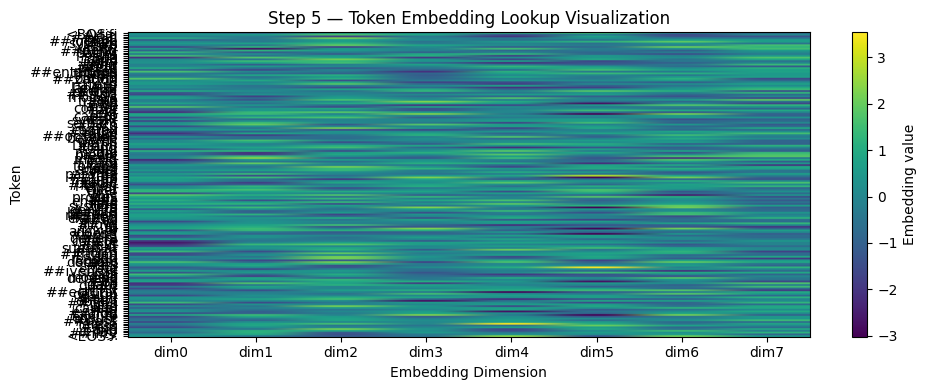

In [16]:
# -----------------------------
# Step 5️.5 — Visualize embeddings (Heatmap)
# -----------------------------
plt.figure(figsize=(10, 4))
plt.imshow(token_embeddings.detach().numpy(), aspect="auto", cmap="viridis")
plt.colorbar(label="Embedding value")

plt.yticks(
    ticks=range(len(tokens)),
    labels=tokens
)

plt.xticks(
    ticks=range(d_model),
    labels=[f"dim{i}" for i in range(d_model)]
)

plt.xlabel("Embedding Dimension")
plt.ylabel("Token")
plt.title("Step 5 — Token Embedding Lookup Visualization")

plt.tight_layout()
plt.show()

In [17]:
token_embeddings.shape[0]

173

In [18]:
# ============================================================
#  6️- Positional Embeddings
# ============================================================

seq_len = token_embeddings.shape[0]

print("Sequence length:", seq_len)
print("Embedding dimension (d_model):", d_model)

Sequence length: 173
Embedding dimension (d_model): 8


In [19]:
seq_len

173

In [20]:
d_model

8

In [21]:
# ============================================================
# 6️.1 Create Learned Positional Embedding Matrix
# ============================================================
positional_embedding = torch.nn.Embedding(
    num_embeddings=seq_len,
    embedding_dim=d_model
)

pos_embedding_matrix = positional_embedding.weight.data

print("\nPositional embedding matrix shape:", pos_embedding_matrix.shape)
print("Sample positional vectors:\n", pos_embedding_matrix)


Positional embedding matrix shape: torch.Size([173, 8])
Sample positional vectors:
 tensor([[ 0.8511,  0.1124,  1.3421,  ..., -0.2520,  1.2577,  1.5373],
        [-0.3239, -0.4780,  1.1156,  ...,  1.2325, -0.4661,  0.0161],
        [ 0.6997,  2.0451, -1.3531,  ...,  0.3594,  0.0798, -0.3954],
        ...,
        [ 0.2764,  0.1768,  0.6249,  ..., -0.6344,  0.9171,  1.1801],
        [ 0.6579,  0.5151, -0.9313,  ...,  0.5961,  1.1803, -0.3367],
        [-1.1733,  1.1104, -0.8850,  ..., -0.2714,  0.4866, -0.0963]])


In [22]:
torch.arange(seq_len).tolist()

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172]

In [23]:
# ============================================================
# 6️.2 Generate Position IDs
# ============================================================
# Position = index in the sequence
position_ids = torch.arange(seq_len)

print("\nPosition IDs:", position_ids.tolist())


Position IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172]


In [24]:
positional_embedding(position_ids)

tensor([[ 0.8511,  0.1124,  1.3421,  ..., -0.2520,  1.2577,  1.5373],
        [-0.3239, -0.4780,  1.1156,  ...,  1.2325, -0.4661,  0.0161],
        [ 0.6997,  2.0451, -1.3531,  ...,  0.3594,  0.0798, -0.3954],
        ...,
        [ 0.2764,  0.1768,  0.6249,  ..., -0.6344,  0.9171,  1.1801],
        [ 0.6579,  0.5151, -0.9313,  ...,  0.5961,  1.1803, -0.3367],
        [-1.1733,  1.1104, -0.8850,  ..., -0.2714,  0.4866, -0.0963]],
       grad_fn=<EmbeddingBackward0>)

In [25]:
# ============================================================
# 6️.3 Positional Embeddings
# ============================================================
position_embeddings = positional_embedding(position_ids)

print("\nPosition embeddings shape:", position_embeddings.shape)


Position embeddings shape: torch.Size([173, 8])


In [26]:
# ============================================================
# 6️.4 Inspect Token Embedding vs Position Embedding
# ============================================================
print("\n Token vs Position embeddings (side-by-side)")
print("-" * 80)

for i in range(seq_len):
    print(f"Position {i}")
    print("  Token        :", tokens[i])
    print("  Token vector :", token_embeddings[i].tolist())
    print("  Position vec :", position_embeddings[i].tolist())
    print("-" * 80)


 Token vs Position embeddings (side-by-side)
--------------------------------------------------------------------------------
Position 0
  Token        : <BOS>
  Token vector : [0.3146284222602844, -1.01921546459198, 0.32316654920578003, -0.017004620283842087, 1.1831436157226562, 1.5537463426589966, -0.16811923682689667, -0.7147703766822815]
  Position vec : [0.8511406779289246, 0.11236411333084106, 1.342063546180725, 1.782325029373169, 0.6595286726951599, -0.2519822120666504, 1.2577214241027832, 1.537253975868225]
--------------------------------------------------------------------------------
Position 1
  Token        : Artifi
  Token vector : [0.30181819200515747, 0.5541663765907288, 1.6746195554733276, 0.8622128367424011, -1.2782657146453857, -0.2005823254585266, -1.5465394258499146, 0.010538180358707905]
  Position vec : [-0.3238753080368042, -0.47801488637924194, 1.115583896636963, 1.5181549787521362, 1.5243690013885498, 1.2325475215911865, -0.466108500957489, 0.0161205381155014

In [27]:
# ============================================================
# 6️.5 Add Token + Position Embeddings (THE CORE OPERATION)
# ============================================================
X = token_embeddings + position_embeddings

print("\nFinal input representation X shape:", X.shape)


Final input representation X shape: torch.Size([173, 8])


In [28]:
token_embeddings + position_embeddings

tensor([[ 1.1658, -0.9069,  1.6652,  ...,  1.3018,  1.0896,  0.8225],
        [-0.0221,  0.0762,  2.7902,  ...,  1.0320, -2.0126,  0.0267],
        [ 0.4904,  1.8298, -3.1689,  ...,  1.0335, -1.2435, -1.7552],
        ...,
        [-0.5396,  1.3332, -0.5857,  ..., -0.0212,  1.2001,  2.3655],
        [ 0.7639,  1.4207, -2.3682,  ...,  0.7408,  1.8145, -1.2160],
        [-0.7798,  0.6965, -2.0677,  ..., -1.5158,  2.5468,  0.3412]],
       grad_fn=<AddBackward0>)

In [29]:
X

tensor([[ 1.1658, -0.9069,  1.6652,  ...,  1.3018,  1.0896,  0.8225],
        [-0.0221,  0.0762,  2.7902,  ...,  1.0320, -2.0126,  0.0267],
        [ 0.4904,  1.8298, -3.1689,  ...,  1.0335, -1.2435, -1.7552],
        ...,
        [-0.5396,  1.3332, -0.5857,  ..., -0.0212,  1.2001,  2.3655],
        [ 0.7639,  1.4207, -2.3682,  ...,  0.7408,  1.8145, -1.2160],
        [-0.7798,  0.6965, -2.0677,  ..., -1.5158,  2.5468,  0.3412]],
       grad_fn=<AddBackward0>)

In [30]:
token_embeddings.detach().numpy()

array([[ 0.31462842, -1.0192155 ,  0.32316655, ...,  1.5537463 ,
        -0.16811924, -0.7147704 ],
       [ 0.3018182 ,  0.5541664 ,  1.6746196 , ..., -0.20058233,
        -1.5465394 ,  0.01053818],
       [-0.20934042, -0.21534152, -1.8157287 , ...,  0.6741007 ,
        -1.3233458 , -1.359769  ],
       ...,
       [-0.8159711 ,  1.1564527 , -1.2106724 , ...,  0.6132566 ,
         0.2830259 ,  1.1854521 ],
       [ 0.10606131,  0.90559894, -1.4368244 , ...,  0.14469725,
         0.634255  , -0.87931615],
       [ 0.39344525, -0.41389975, -1.1826732 , ..., -1.2444793 ,
         2.0601478 ,  0.43746954]], dtype=float32)

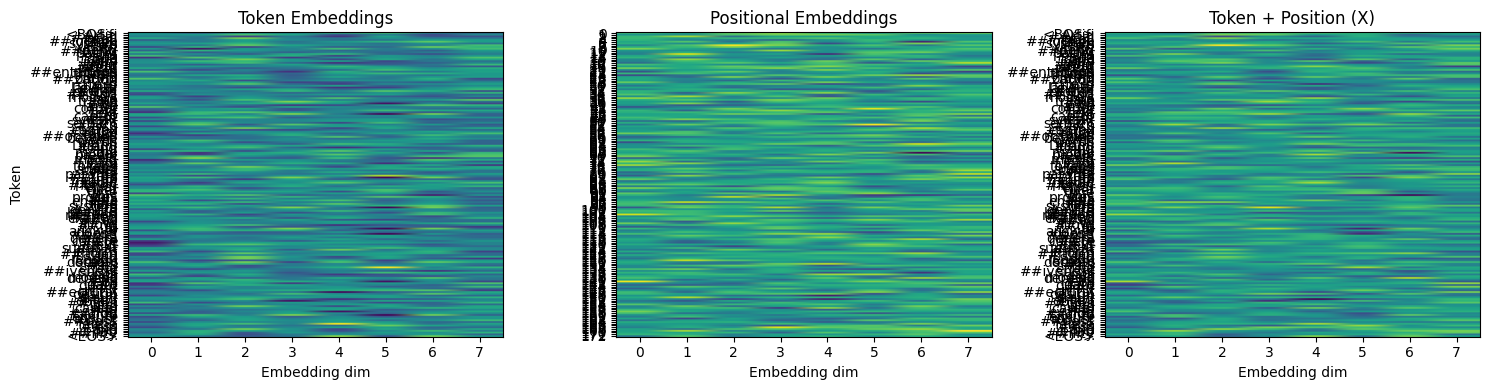

In [31]:
# ============================================================
# 6️.6 Visualize (Token, Position, Sum)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Token embeddings
axes[0].imshow(token_embeddings.detach().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("Token Embeddings")
axes[0].set_ylabel("Token")
axes[0].set_xlabel("Embedding dim")
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(tokens)

# Positional embeddings
axes[1].imshow(position_embeddings.detach().numpy(), aspect="auto", cmap="viridis")
axes[1].set_title("Positional Embeddings")
axes[1].set_xlabel("Embedding dim")
axes[1].set_yticks(range(seq_len))
axes[1].set_yticklabels(position_ids.tolist())

# Combined embeddings
axes[2].imshow(X.detach().numpy(), aspect="auto", cmap="viridis")
axes[2].set_title("Token + Position (X)")
axes[2].set_xlabel("Embedding dim")
axes[2].set_yticks(range(seq_len))
axes[2].set_yticklabels(tokens)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# 7- Transformer Block (Repeated N Times)
# ============================================================

@dataclass

class Config:
    d_model: int = 128
    n_heads: int = 4 # Q - K - V
    n_layers: int = 2
    d_ff: int = 4 * 128
    max_len: int = 200
    dropout: float = 0.1 # 10% of the feature detectors (neurons) will be ommitted

cfg = Config()

In [33]:
cfg

Config(d_model=128, n_heads=4, n_layers=2, d_ff=512, max_len=200, dropout=0.1)

In [34]:
len(tokens)

173

In [35]:
torch.tril(torch.ones(3, 3)).bool()

tensor([[ True, False, False],
        [ True,  True, False],
        [ True,  True,  True]])

In [36]:
# ============================================================
# 8️- Masking helpers (Causal + Padding)
# ============================================================
def make_causal_mask(seq_len: int, device: str) -> torch.Tensor:
    # mask shape: (1, 1, seq_len, seq_len) for broadcasting over batch & heads
    # True = keep, False = mask-out

    mask = torch.tril(torch.ones(seq_len, seq_len, device=device)).bool()

    return mask.view(1, 1, seq_len, seq_len)

def make_padding_mask(input_ids: torch.Tensor, pad_id: int) -> torch.Tensor:
    # input_ids: (B, T)
    # returns: (B, 1, 1, T) True where NOT pad
    return (input_ids != pad_id).view(input_ids.size(0), 1, 1, input_ids.size(1))

In [37]:
# ============================================================
# 7️ + 8️ + 9️ +  + 1️1️  Multi-Head Masked Self-Attention
# ============================================================

class MultiHeadSelfAttention(nn.Module):

    def __init__(self, d_model: int, n_heads: int, dropout: float):

        super().__init__()

        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model # The dimension inside Q - K - V # 8
        self.n_heads = n_heads # The number of heads that we want to provide to the attention layer
        self.d_head = d_model // n_heads # 8 / 2 = 4

        # 7️- Q, K, V projections (three linear layers)
        self.w_q = nn.Linear(d_model, d_model, bias=False) # X => Linear => Y (Vector) (Q = X * W)
        self.w_k = nn.Linear(d_model, d_model, bias=False) #  X => Linear => Y (Vector) (K = X * W)
        self.w_v = nn.Linear(d_model, d_model, bias=False) #  X => Linear => Y (Vector) (V = X * W)

        # output projection (after concatenating heads)
        self.w_o = nn.Linear(d_model, d_model, bias=False) # Linear (Weights of the output after concat heads)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:

        # x: (B, T, d_model)
        B, T, C = x.shape

        # 7️- Project to Q,K,V
        q = self.w_q(x)  # (B, T, C) # Linear Layer X => Linear => Q
        k = self.w_k(x) # X -> Vector Embedding
        v = self.w_v(x)

        # Split heads: (B, n_heads, T, d_head)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # 8️-a Scores = QK^T
        scores = (q @ k.transpose(-2, -1))  # (B, h, T, T) # Q * K

        # 8️- b Scaling by sqrt(d_k)
        scores = scores / math.sqrt(self.d_head) # (Q * K) / sqrt(Dim of K)

        # 8️- c Masking (causal & padding)
        # We use -inf to kill masked positions before softmax.
        scores = scores.masked_fill(~attn_mask, float("-inf"))

        # 9️- Softmax -> attention weights
        attn = F.softmax(scores, dim=-1) # Softmax function limits the bound between (0, 1)

        # dropout on attention weights (common)
        attn = self.dropout(attn) # Zeros out some of the elements inside the attention weights matrix

        # 10- Weighted sum of values
        out = attn @ v  # (B, h, T, d_head)

        # 1️1️-Concatenate heads back: (B, T, C)
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        # Final projection
        out = self.w_o(out) # Concatenate the different outputs of all attention heads
        return out

In [38]:
# ------------------------------------------------------------
# Helper: visualize Q, K, V and Attention
# ------------------------------------------------------------
def visualize_qkv_and_attention(
    mha: MultiHeadSelfAttention,
    x: torch.Tensor,
    attn_mask: torch.Tensor,
    tokens: list,
    head_idx: int = 0,
    batch_idx: int = 0
):
    """
    Visualize Q, K, V vectors and attention maps
    """

    B, T, C = x.shape

    # -----------------------------
    # Step 1: Compute Q, K, V
    # -----------------------------
    with torch.no_grad():
        q = mha.w_q(x)
        k = mha.w_k(x)
        v = mha.w_v(x)

        q = q.view(B, T, mha.n_heads, mha.d_head).transpose(1, 2)
        k = k.view(B, T, mha.n_heads, mha.d_head).transpose(1, 2)
        v = v.view(B, T, mha.n_heads, mha.d_head).transpose(1, 2)

    # Select one batch + one head
    Q = q[batch_idx, head_idx]  # (T, d_head)
    K = k[batch_idx, head_idx]
    V = v[batch_idx, head_idx]

    # -----------------------------
    # Step 2: Attention computation
    # -----------------------------
    scores = (Q @ K.T) / math.sqrt(mha.d_head)
    scores = scores.masked_fill(~attn_mask[batch_idx, 0], float("-inf"))
    attn = F.softmax(scores, dim=-1)

    # -----------------------------
    # Step 3: Plot Heatmaps
    # -----------------------------
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Q
    axes[0].imshow(Q.numpy(), aspect="auto", cmap="viridis")
    axes[0].set_title("Query (Q)")
    axes[0].set_yticks(range(T))
    axes[0].set_yticklabels(tokens)
    axes[0].set_xlabel("d_head")

    # K
    axes[1].imshow(K.numpy(), aspect="auto", cmap="viridis")
    axes[1].set_title("Key (K)")
    axes[1].set_yticks(range(T))
    axes[1].set_yticklabels(tokens)
    axes[1].set_xlabel("d_head")

    # V
    axes[2].imshow(V.numpy(), aspect="auto", cmap="viridis")
    axes[2].set_title("Value (V)")
    axes[2].set_yticks(range(T))
    axes[2].set_yticklabels(tokens)
    axes[2].set_xlabel("d_head")

    # Attention
    axes[3].imshow(attn.numpy(), cmap="plasma")
    axes[3].set_title("Attention Weights (Softmax)")
    axes[3].set_xticks(range(T))
    axes[3].set_xticklabels(tokens, rotation=45)
    axes[3].set_yticks(range(T))
    axes[3].set_yticklabels(tokens)

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Step 4: Print vectors (Readable)
    # -----------------------------
    print("\n Query / Key / Value vectors (head =", head_idx, ")")
    print("-" * 70)
    for i, tok in enumerate(tokens):
        print(f"Token: {tok}")
        print(" Q:", Q[i].tolist())
        print(" K:", K[i].tolist())
        print(" V:", V[i].tolist())
        print("-" * 70)

In [39]:
device = "cpu" # GPU => CPU using MatPlotLib

T = len(tokens)

attn_mask = make_causal_mask(T, device)

X = torch.randn(T, d_model)

X = X.unsqueeze(0) # Add batch dim

d_model = 8 # Vector contains 8 values
n_heads = 2 # Number of heads just two 2
dropout = 0.0

mha = MultiHeadSelfAttention(
    d_model=d_model, # 8 values
    n_heads=n_heads, # 2 heads (1 head recieves 4 values (Q - K - V))
    dropout=dropout
)


print("X shape:", X.shape) # (1, T, d_model)
print("Attention mask shape:", attn_mask.shape)  # (1, 1, T, T)
print("Tokens:", tokens)

X shape: torch.Size([1, 173, 8])
Attention mask shape: torch.Size([1, 1, 173, 173])
Tokens: ['<BOS>', 'Artifi', '##cial', 'intell', '##igence', 'system', '##s', 'learn', 'by', 'identi', '##fying', 'patter', '##ns', 'in', 'data', 'and', 'refini', '##ng', 'their', 'intern', '##al', 'repres', '##entations', 'throug', '##h', 'optimi', '##zation', '.', 'In', 'natura', '##l', 'langua', '##ge', 'proces', '##sing', ',', 'models', 'are', 'traine', '##d', 'on', 'large', 'corpor', '##a', 'of', 'text', 'to', 'captur', '##e', 'syntax', ',', 'semant', '##ics', ',', 'and', 'contex', '##tual', 'relati', '##onships', 'betwee', '##n', 'words', '.', 'During', 'traini', '##ng', ',', 'the', 'model', 'predic', '##ts', 'missin', '##g', 'or', 'future', 'tokens', 'and', 'adjust', '##s', 'its', 'parame', '##ters', 'to', 'minimi', '##ze', 'predic', '##tion', 'error', '.', 'Over', 'time', ',', 'this', 'proces', '##s', 'enable', '##s', 'the', 'system', 'to', 'genera', '##lize', 'beyond', 'memori', '##zed', 'exampl

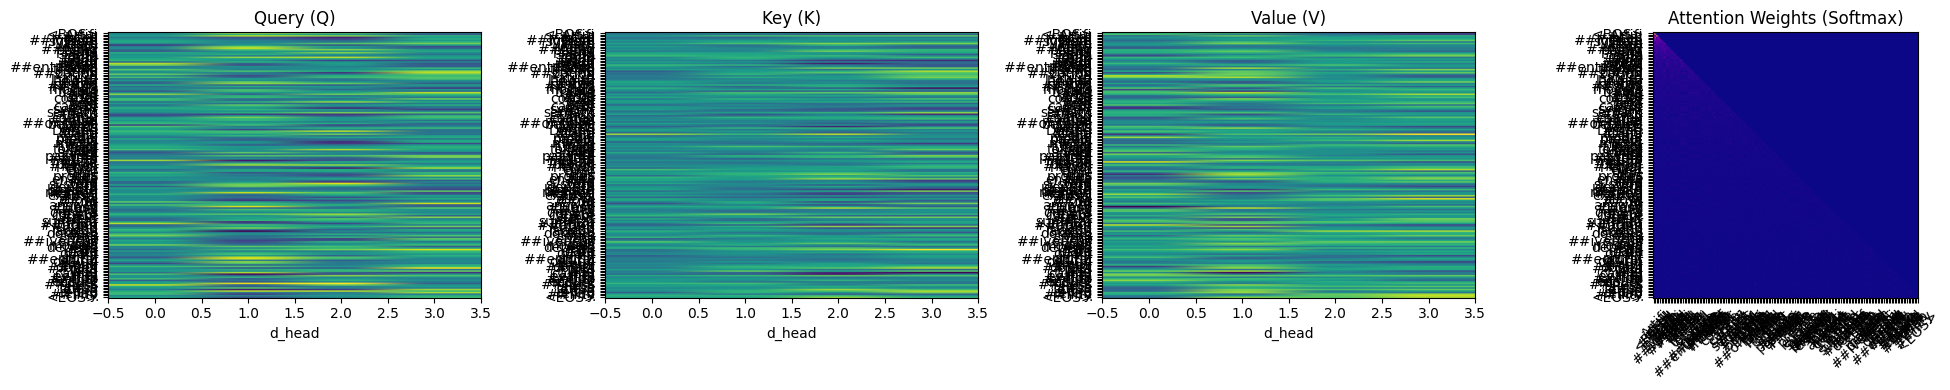


 Query / Key / Value vectors (head = 1 )
----------------------------------------------------------------------
Token: <BOS>
 Q: [-0.033972226083278656, 1.2615315914154053, 0.9104384779930115, -0.2484152615070343]
 K: [-0.3917655944824219, 0.054436154663562775, 0.1368657350540161, 0.4396297335624695]
 V: [0.3738189935684204, 0.6749882698059082, -1.003108024597168, -1.4579136371612549]
----------------------------------------------------------------------
Token: Artifi
 Q: [-0.13021910190582275, 0.3959023058414459, 0.023149849846959114, -0.7436208724975586]
 K: [-0.3223266303539276, -0.562699556350708, -0.9247670769691467, -0.7661349177360535]
 V: [0.7152796983718872, -0.5832441449165344, -0.6752501130104065, -1.4814565181732178]
----------------------------------------------------------------------
Token: ##cial
 Q: [0.13545627892017365, 1.1790403127670288, 0.9282450079917908, 0.40008026361465454]
 K: [0.06655744463205338, 0.7760579586029053, 0.9097294211387634, 0.9982301592826843]
 V

In [40]:
visualize_qkv_and_attention(
    mha=mha, # Mutli Head Attention
    x=X,
    attn_mask=attn_mask,
    tokens=tokens,
    head_idx=1
)

In [41]:
# ============================================================
# 1️3️ Feed-Forward Network (MLP / FFN)
# ============================================================
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__() # Must to work properly

        self.fc1 = nn.Linear(d_model, d_ff) # d_model = Vector Embedding = 8 => 16
        self.fc2 = nn.Linear(d_ff, d_model) # 16 => 8
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # GELU is widely used (GPT-2 style)
        x = self.fc1(x)
        x = F.gelu(x) # Gaussian Error Linear Unit (GELU)
        x = self.dropout(x) # Dropout zeros out some of the elements
        x = self.fc2(x)
        return x

In [42]:
feed_forward_layer = FeedForward(d_model=8, d_ff=16, dropout=0)
feed_forward_layer(X)

tensor([[[ 0.3656,  0.2042,  0.1256,  ..., -0.1817,  0.0390,  0.4895],
         [ 0.3615,  0.0153,  0.3333,  ...,  0.0939,  0.1280,  0.2633],
         [-0.0138,  0.4735,  0.3582,  ..., -0.3291, -0.1822,  0.2442],
         ...,
         [ 0.3639, -0.2863, -0.0200,  ...,  0.4998,  0.6368, -0.3251],
         [-0.2684,  0.1900,  0.2889,  ..., -0.2035,  0.1091, -0.2859],
         [-0.0520,  0.1217, -0.1826,  ...,  0.0183, -0.0355,  0.0129]]],
       grad_fn=<ViewBackward0>)

In [43]:
# ============================================================
# Transformer Block: (Pre-LN)
# 1️2️- Residual + LayerNorm (around attention)
# 1️4️- Residual + LayerNorm (around FFN)
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(self, cfg: Config):

        super().__init__()

        self.ln1 = nn.LayerNorm(cfg.d_model) # will process the outputs of attention layer

        self.attn = MultiHeadSelfAttention(cfg.d_model, cfg.n_heads, cfg.dropout)

        self.ln2 = nn.LayerNorm(cfg.d_model) # will process the outputs of feed forward layer

        self.ffn = FeedForward(cfg.d_model, cfg.d_ff, cfg.dropout)

        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:

        # 1️2️- Attention residual path (Pre-LN)
        x = x + self.dropout(self.attn(self.ln1(x), attn_mask))

        # 1️4️- FFN residual path (Pre-LN)
        x = x + self.dropout(self.ffn(self.ln2(x))) # x -> (layer norm -> feed forward network -> dropout) + x
        return x

In [44]:
transformer_block = TransformerBlock(cfg)
transformer_block

TransformerBlock(
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (attn): MultiHeadSelfAttention(
    (w_q): Linear(in_features=128, out_features=128, bias=False)
    (w_k): Linear(in_features=128, out_features=128, bias=False)
    (w_v): Linear(in_features=128, out_features=128, bias=False)
    (w_o): Linear(in_features=128, out_features=128, bias=False)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (ffn): FeedForward(
    (fc1): Linear(in_features=128, out_features=512, bias=True)
    (fc2): Linear(in_features=512, out_features=128, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dropout): Dropout(p=0.1, inplace=False)
)

In [45]:
cfg.n_layers

2

In [46]:
# ============================================================
# Full Decoder-Only Transformer (GPT-like)
# ============================================================

class TinyGPT(nn.Module):

    def __init__(self, cfg: Config, vocab_size: int, pad_id: int):

        super().__init__()

        self.cfg = cfg
        self.pad_id = pad_id

        # 5️- Token embeddings + 6️- positional embeddings
        self.tok_emb = nn.Embedding(vocab_size, cfg.d_model) # d_model = Vector of len 8
        self.pos_emb = nn.Embedding(cfg.max_len, cfg.d_model) # d_model = Vector of len 8

        self.drop = nn.Dropout(cfg.dropout) # It prevents overfitting

        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])

        self.ln_f = nn.LayerNorm(cfg.d_model)

        # 1️5️- Final linear layer (unembedding to logits)
        self.head = nn.Linear(cfg.d_model, vocab_size, bias=False)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # input_ids: (B, T)

        B, T = input_ids.shape
        assert T <= self.cfg.max_len, "Sequence too long for max_len"

        # Build masks: causal AND padding
        causal = make_causal_mask(T, input_ids.device)                 # (1,1,T,T)
        padmask = make_padding_mask(input_ids, self.pad_id).to(input_ids.device)  # (B,1,1,T)
        attn_mask = causal & padmask  # broadcast to (B,1,T,T)

        # 5️- Token embedding lookup
        tok = self.tok_emb(input_ids)  # (B, T, d_model)

        # 6️- Positional embeddings
        pos_ids = torch.arange(T, device=input_ids.device).unsqueeze(0)  # (1, T)
        pos = self.pos_emb(pos_ids)                                      # (1, T, d_model)

        # Token+Position sum
        x = self.drop(tok + pos) # some of the elements will be zeroed out

        #  N transformer layers
        for block in self.blocks:
            x = block(x, attn_mask)

        x = self.ln_f(x)

        # 1️5️- logits over vocab for each position
        logits = self.head(x)  # (B, T, vocab_size)
        return logits

In [47]:
len(tokens)

173

In [48]:
my_gpt = TinyGPT(cfg, pad_id=2, vocab_size=173)
my_gpt

TinyGPT(
  (tok_emb): Embedding(173, 128)
  (pos_emb): Embedding(200, 128)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (w_q): Linear(in_features=128, out_features=128, bias=False)
        (w_k): Linear(in_features=128, out_features=128, bias=False)
        (w_v): Linear(in_features=128, out_features=128, bias=False)
        (w_o): Linear(in_features=128, out_features=128, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementw

In [49]:
pad_id = stoi[PAD]
model = TinyGPT(cfg, vocab_size, pad_id).to(device)

I went to the store.

<BOS> I went to the store.

In [50]:
[50, 60, 10000]

[50, 60, 10000]

In [51]:
# ============================================================
# Training helper (teacher forcing)
# ============================================================.

def batchify_single_sequence(seq_ids: List[int], block_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
    # Create (x, y) where y is x shifted by 1 (X = I went to the) (Y = Went to the store)
    # x: [t0..t_{n-2}] -> y: [t1..t_{n-1}]
    seq = torch.tensor(seq_ids, dtype=torch.long) # torch.int64 (signed)

    if len(seq) < block_size + 1:
        # pad to fit
        needed = (block_size + 1) - len(seq)
        seq = torch.cat([seq, torch.full((needed,), pad_id, dtype=torch.long)])

    x = seq[0:block_size].unsqueeze(0) # I went to the.
    y = seq[1:block_size+1].unsqueeze(0) # went to the store.
    return x, y

In [52]:
raw_text

'Artificial intelligence systems learn by identifying patterns in data and refining their internal representations through optimization. In natural language processing, models are trained on large corpora of text to capture syntax, semantics, and contextual relationships between words. During training, the model predicts missing or future tokens and adjusts its parameters to minimize prediction error. Over time, this process enables the system to generalize beyond memorized examples, allowing it to answer questions, generate coherent text, summarize information, and reason across domains. The effectiveness of such models depends on data quality, architectural design, training objectives, and careful evaluation to ensure robustness, fairness, and reliability.'

In [53]:
my_result = batchify_single_sequence(token_ids, block_size=10)

/tmp/ipython-input-3670271547.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seq = torch.tensor(seq_ids, dtype=torch.long) # torch.int64 (signed)


In [54]:
ids_to_tokens(my_result[0].squeeze().tolist())

['<BOS>',
 'Artifi',
 '##cial',
 'intell',
 '##igence',
 'system',
 '##s',
 'learn',
 'by',
 'identi']

In [55]:
ids_to_tokens(my_result[1].squeeze().tolist())

['Artifi',
 '##cial',
 'intell',
 '##igence',
 'system',
 '##s',
 'learn',
 'by',
 'identi',
 '##fying']

In [56]:
raw_text

'Artificial intelligence systems learn by identifying patterns in data and refining their internal representations through optimization. In natural language processing, models are trained on large corpora of text to capture syntax, semantics, and contextual relationships between words. During training, the model predicts missing or future tokens and adjusts its parameters to minimize prediction error. Over time, this process enables the system to generalize beyond memorized examples, allowing it to answer questions, generate coherent text, summarize information, and reason across domains. The effectiveness of such models depends on data quality, architectural design, training objectives, and careful evaluation to ensure robustness, fairness, and reliability.'

In [57]:
block_size = min(len(ids)-1, 32)

batchify_single_sequence(ids, block_size)

(tensor([[ 42,  46,   3,  82,  14, 116,  28,  88,  60,  79,   9, 101,  24,  80,
           66,  54, 107,  23, 119,  83,   1, 110,   7, 121,  12,  98,  37,  41,
           48,  94,  19,  86]]),
 tensor([[ 46,   3,  82,  14, 116,  28,  88,  60,  79,   9, 101,  24,  80,  66,
           54, 107,  23, 119,  83,   1, 110,   7, 121,  12,  98,  37,  41,  48,
           94,  19,  86,  11]]))

In [58]:
!nvidia-smi

Fri Jan 30 19:12:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             16W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [59]:
3e-3

0.003

In [60]:
# Build a small training sample from our ids

block_size = min(len(ids)-1, 32)
x_train, y_train = batchify_single_sequence(ids, block_size)

x_train, y_train = x_train.to(device), y_train.to(device)

optim = torch.optim.AdamW(model.parameters(), lr=3e-3)

# quick tiny training

model.train() # Set model mode into training mode

for step in range(20):

    optim.zero_grad() # The gradients are zeroed in every epoch

    logits = model(x_train)                      # (1, T, V)

    loss = F.cross_entropy( # Loss function
        logits.view(-1, vocab_size), # Actual Output vector
        y_train.view(-1), # Desired output vector
        ignore_index=pad_id
    )
    loss.backward() # executes the backpropagation algorithm
    optim.step() # Implements the AdamW optimizer


print("\n Tiny training done. Loss:", float(loss.detach().cpu()))


 Tiny training done. Loss: 0.02228837087750435


In [61]:
prompt = "Artificial intelligence systems learn by adjust During training reason predict pattern repres tokens"
prompt

'Artificial intelligence systems learn by adjust During training reason predict pattern repres tokens'

In [62]:
inference_tokens = toy_subword_tokenize(prompt)

In [63]:
model = TinyGPT(cfg, pad_id=2, vocab_size=173)

In [64]:
tokens[model(torch.tensor(tokens_to_ids(tokens)).unsqueeze(0))[0, -1].argmax(0)]

'##s'

In [65]:
idxs = torch.topk(model(torch.tensor(tokens_to_ids(tokens)).unsqueeze(0))[0, -1], k=5)
for prob, idx in zip(idxs.values, idxs.indices):
    print(f"Token: {tokens[idx]} | Prob: {prob:.2f}%")

Token: ##cial | Prob: 1.32%
Token: patter | Prob: 1.25%
Token: summar | Prob: 1.21%
Token: relati | Prob: 1.19%
Token: traini | Prob: 1.18%


In [66]:
logits = torch.tensor([2.5, 1.3, 0.2, -0.5, -1.2])

token_labels = [f"token_{i}" for i in range(len(logits))]

print("Original logits:", logits.tolist())


Original logits: [2.5, 1.2999999523162842, 0.20000000298023224, -0.5, -1.2000000476837158]


In [67]:
1e-6

1e-06

In [68]:
def apply_temperature(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    temperature = max(1e-6, float(temperature))
    return logits / temperature

print(f"Logits: {apply_temperature(logits, temperature=1.5)}")

print(f"Probs: {torch.softmax(apply_temperature(logits, temperature=1.5), dim=-1)}")

Logits: tensor([ 1.6667,  0.8667,  0.1333, -0.3333, -0.8000])
Probs: tensor([0.5304, 0.2383, 0.1145, 0.0718, 0.0450])


Original logits: [2.5, 1.2999999523162842, 0.20000000298023224, -0.5, -1.2000000476837158]

 Temperature = 0.5
Scaled logits : [5.0, 2.5999999046325684, 0.4000000059604645, -1.0, -2.4000000953674316]
Probabilities : [0.9059121608734131, 0.08218248933553696, 0.009106081910431385, 0.0022455318830907345, 0.0005537412944249809]

 Temperature = 1.0
Scaled logits : [2.5, 1.2999999523162842, 0.20000000298023224, -0.5, -1.2000000476837158]
Probabilities : [0.6775234937667847, 0.20406614243984222, 0.06792772561311722, 0.03373190760612488, 0.016750769689679146]

 Temperature = 1.5
Scaled logits : [1.6666666269302368, 0.8666666150093079, 0.13333334028720856, -0.3333333432674408, -0.800000011920929]
Probabilities : [0.5304064750671387, 0.2383269965648651, 0.11446972191333771, 0.07178270816802979, 0.0450141541659832]

 Temperature = 2.0
Scaled logits : [1.25, 0.6499999761581421, 0.10000000149011612, -0.25, -0.6000000238418579]
Probabilities : [0.4452725052833557, 0.2443707287311554, 0.1409896463155

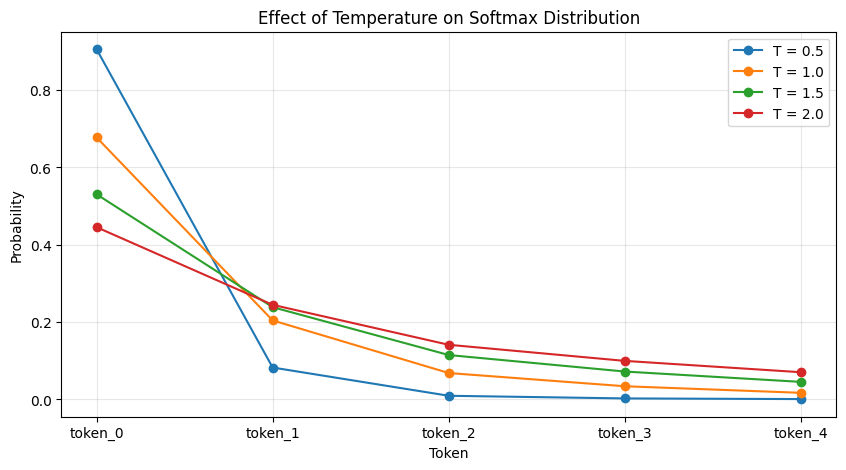

In [69]:
# ============================================================
# 1️6️- Softmax: probabilities for next token
# ============================================================
# We'll implement sampling helpers now:
# 1️7 Temperature
# 1️8 Top-K
# 1️9 Top-P
# 2️0 Sample
# ============================================================
# -----------------------------
# Example logits (simulating model output for ONE token)
# -----------------------------
# In practice: logits = model(...)[..., -1, :]

logits = torch.tensor([2.5, 1.3, 0.2, -0.5, -1.2])

token_labels = [f"token_{i}" for i in range(len(logits))]

print("Original logits:", logits.tolist())

# -----------------------------
# Temperature function (your exact logic)
# -----------------------------

def apply_temperature(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    temperature = max(1e-6, float(temperature))
    return logits / temperature

# -----------------------------
# Temperatures to visualize
# -----------------------------
temperatures = [0.5, 1.0, 1.5, 2.0]

# -----------------------------
# Collect probabilities
# -----------------------------
all_probs = []

for T in temperatures:
    scaled_logits = apply_temperature(logits, T)
    probs = F.softmax(scaled_logits, dim=-1) # softmax bounds the logits between 0-1
    all_probs.append(probs)

    print(f"\n Temperature = {T}")
    print("Scaled logits :", scaled_logits.tolist())
    print("Probabilities :", probs.tolist())

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(10, 5))

for probs, T in zip(all_probs, temperatures):
    plt.plot(
        probs.detach().numpy(),
        marker="o",
        label=f"T = {T}"
    )

plt.xticks(range(len(token_labels)), token_labels)
plt.ylabel("Probability")
plt.xlabel("Token")
plt.title("Effect of Temperature on Softmax Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
0.7685248255729675 + 0.23147521913051605

1.0000000447034836

Original logits: [2.5, 1.2999999523162842, 0.20000000298023224, -0.5, -1.2000000476837158]

 Top-K = 0
Filtered logits: [2.5, 1.2999999523162842, 0.20000000298023224, -0.5, -1.2000000476837158]
Probabilities  : [0.6775234937667847, 0.20406614243984222, 0.06792772561311722, 0.03373190760612488, 0.016750769689679146]

 Top-K = 1
Filtered logits: [2.5, -inf, -inf, -inf, -inf]
Probabilities  : [1.0, 0.0, 0.0, 0.0, 0.0]

 Top-K = 2
Filtered logits: [2.5, 1.2999999523162842, -inf, -inf, -inf]
Probabilities  : [0.7685248255729675, 0.23147521913051605, 0.0, 0.0, 0.0]

 Top-K = 3
Filtered logits: [2.5, 1.2999999523162842, 0.20000000298023224, -inf, -inf]
Probabilities  : [0.7135451436042786, 0.21491564810276031, 0.07153921574354172, 0.0, 0.0]


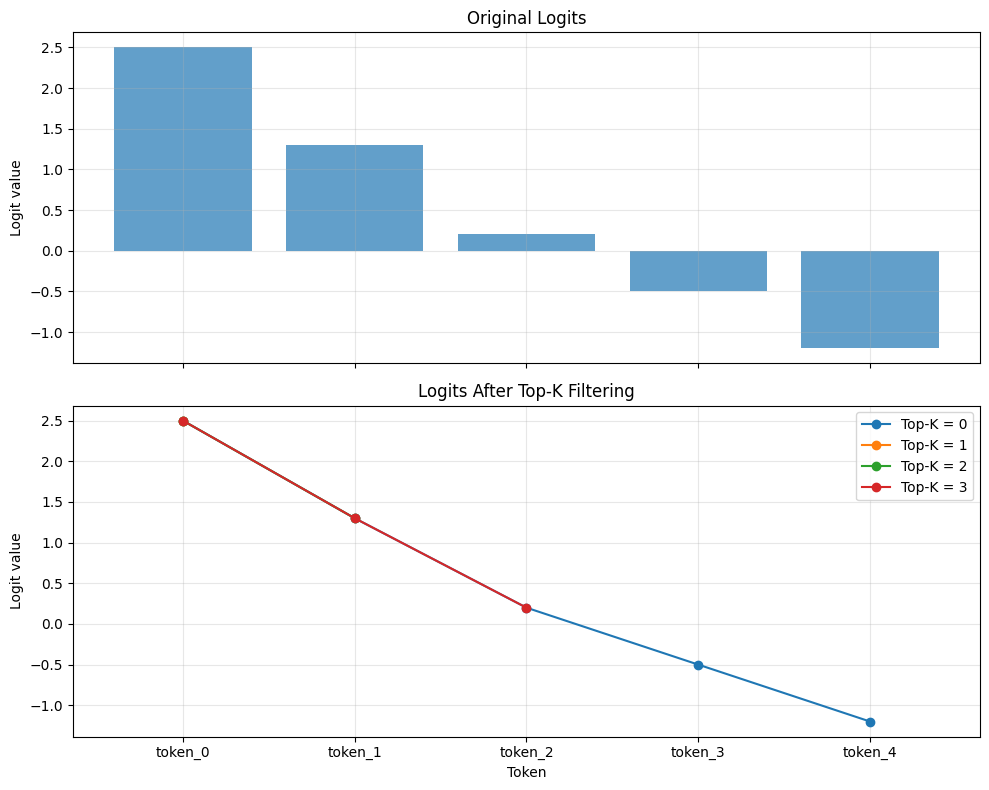

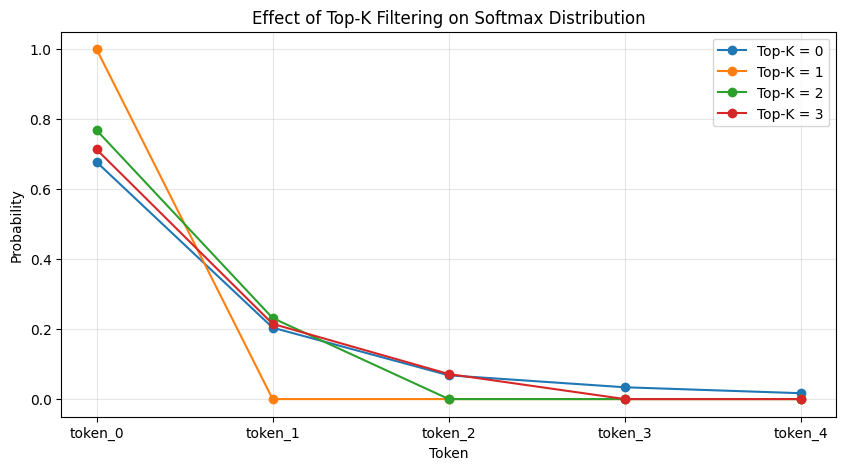

In [71]:
# -----------------------------
# Example logits (single-token prediction)
# -----------------------------
logits = torch.tensor([2.5, 1.3, 0.2, -0.5, -1.2])
token_labels = [f"token_{i}" for i in range(len(logits))]

print("Original logits:", logits.tolist())

# -----------------------------
# Top-K function (YOUR exact logic)
# -----------------------------

def top_k_filter(logits: torch.Tensor, k: int) -> torch.Tensor:

    if k is None or k <= 0:
        return logits


    k = min(k, logits.size(-1))
    values, _ = torch.topk(logits, k, dim=-1)

    cutoff = values[..., -1].unsqueeze(-1) # Add batch size
    return logits.masked_fill(logits < cutoff, float("-inf")) # - infinity

# -----------------------------
# Different K values to visualize
# -----------------------------
k_values = [0, 1, 2, 3]

# -----------------------------
# Apply Top-K and collect results
# -----------------------------
filtered_logits_all = []
probs_all = []

for k in k_values:

    filtered_logits = top_k_filter(logits.clone(), k) # unnormalized scores
    probs = F.softmax(filtered_logits, dim=-1)

    filtered_logits_all.append(filtered_logits)
    probs_all.append(probs)

    print(f"\n Top-K = {k}")
    print("Filtered logits:", filtered_logits.tolist())
    print("Probabilities  :", probs.tolist())

# -----------------------------
# Visualization — logits before vs after
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Original logits
axes[0].bar(token_labels, logits.tolist(), alpha=0.7)
axes[0].set_title("Original Logits")
axes[0].set_ylabel("Logit value")
axes[0].grid(True, alpha=0.3)

# Filtered logits
for filtered, k in zip(filtered_logits_all, k_values):
    axes[1].plot(
        filtered.tolist(),
        marker="o",
        label=f"Top-K = {k}"
    )

axes[1].set_title("Logits After Top-K Filtering")
axes[1].set_ylabel("Logit value")
axes[1].set_xlabel("Token")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Visualization — probability distributions
# -----------------------------
plt.figure(figsize=(10, 5))

for probs, k in zip(probs_all, k_values):
    plt.plot(
        probs.detach().numpy(),
        marker="o",
        label=f"Top-K = {k}"
    )

plt.xticks(range(len(token_labels)), token_labels)
plt.ylabel("Probability")
plt.xlabel("Token")
plt.title("Effect of Top-K Filtering on Softmax Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Original logits: [2.5, 1.2999999523162842, 0.20000000298023224, -0.5, -1.2000000476837158]

 Top-P = 0.5
Filtered logits: [2.5, -inf, -inf, -inf, -inf]
Probabilities  : [1.0, 0.0, 0.0, 0.0, 0.0]

 Top-P = 0.7
Filtered logits: [2.5, 1.2999999523162842, -inf, -inf, -inf]
Probabilities  : [0.7685248255729675, 0.23147521913051605, 0.0, 0.0, 0.0]

 Top-P = 0.9
Filtered logits: [2.5, 1.2999999523162842, 0.20000000298023224, -inf, -inf]
Probabilities  : [0.7135451436042786, 0.21491564810276031, 0.07153921574354172, 0.0, 0.0]

 Top-P = 0.99
Filtered logits: [2.5, 1.2999999523162842, 0.20000000298023224, -0.5, -1.2000000476837158]
Probabilities  : [0.6775234937667847, 0.20406614243984222, 0.06792772561311722, 0.03373190760612488, 0.016750769689679146]


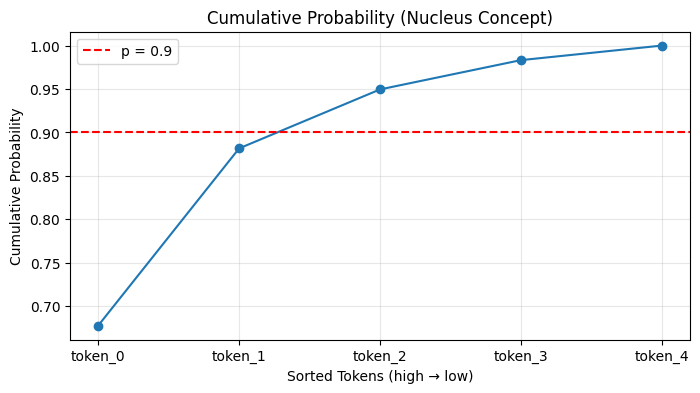

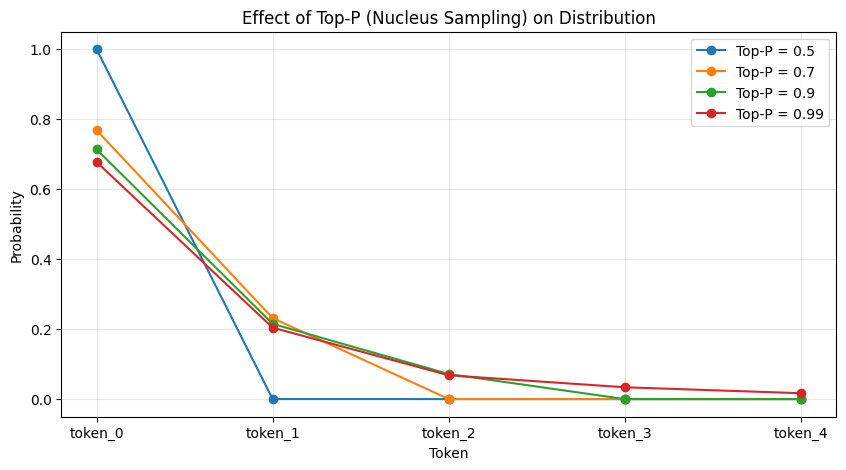

In [72]:
# -----------------------------
# Example logits (single-token prediction)
# -----------------------------

logits = torch.tensor([2.5, 1.3, 0.2, -0.5, -1.2])

token_labels = [f"token_{i}" for i in range(len(logits))]

print("Original logits:", logits.tolist())


# -----------------------------
# Top-P function (YOUR exact logic)
# -----------------------------

def top_p_filter(logits: torch.Tensor, p: float) -> torch.Tensor:
    if p is None or p <= 0 or p >= 1:
        return logits

    sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
    probs = F.softmax(sorted_logits, dim=-1)

    cumprobs = torch.cumsum(probs, dim=-1) # Cumulative Summation

    cutoff_mask = cumprobs > p
    cutoff_mask[..., 1:] = cutoff_mask[..., :-1].clone()
    cutoff_mask[..., 0] = False

    sorted_logits = sorted_logits.masked_fill(cutoff_mask, float("-inf"))
    unsorted = torch.empty_like(sorted_logits).scatter(-1, sorted_idx, sorted_logits)
    return unsorted

# -----------------------------
# Different P values to visualize
# -----------------------------
p_values = [0.5, 0.7, 0.9, 0.99]

filtered_logits_all = []
probs_all = []

for p in p_values:
    filtered_logits = top_p_filter(logits.clone(), p)
    probs = F.softmax(filtered_logits, dim=-1)

    filtered_logits_all.append(filtered_logits)
    probs_all.append(probs)

    print(f"\n Top-P = {p}")
    print("Filtered logits:", filtered_logits.tolist())
    print("Probabilities  :", probs.tolist())

# -----------------------------
# Visualization 1 — cumulative probability (core idea of Top-P)
# -----------------------------
sorted_logits, _ = torch.sort(logits, descending=True)
sorted_probs = F.softmax(sorted_logits, dim=-1)
cumprobs = torch.cumsum(sorted_probs, dim=-1)

plt.figure(figsize=(8, 4))
plt.plot(cumprobs.numpy(), marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="p = 0.9")
plt.xticks(range(len(token_labels)), token_labels)
plt.ylabel("Cumulative Probability")
plt.xlabel("Sorted Tokens (high → low)")
plt.title("Cumulative Probability (Nucleus Concept)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# Visualization 2 — probabilities after Top-P
# -----------------------------
plt.figure(figsize=(10, 5))

for probs, p in zip(probs_all, p_values):
    plt.plot(
        probs.detach().numpy(),
        marker="o",
        label=f"Top-P = {p}"
    )

plt.xticks(range(len(token_labels)), token_labels)
plt.ylabel("Probability")
plt.xlabel("Token")
plt.title("Effect of Top-P (Nucleus Sampling) on Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Final probabilities after 17→18→19:
token_0: 0.7685
token_1: 0.2315
token_2: 0.0000
token_3: 0.0000
token_4: 0.0000

 Greedy choice (argmax): token_0

 Sampling results over 30 runs:
token_0: 22
token_1: 8
token_2: 0
token_3: 0
token_4: 0


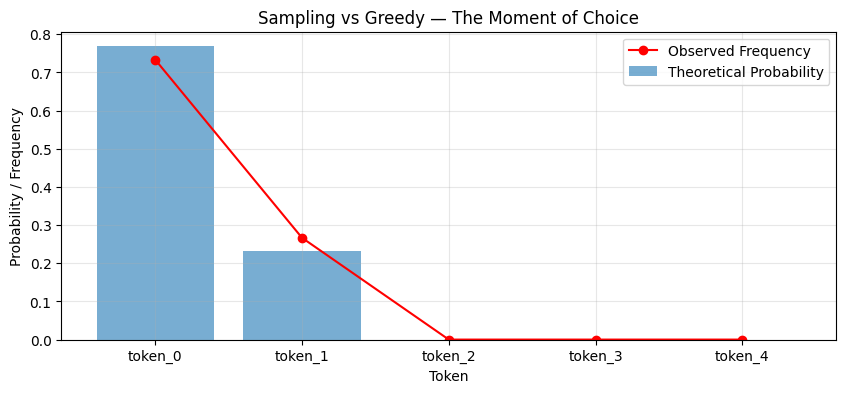

In [95]:
# ============================================================
# 2️0️ Sampling the Next Token
# ============================================================
# -----------------------------
# Sampling function (YOUR exact logic)
# -----------------------------

@torch.no_grad()  # Stop gradient tracking becuase we are currently in inference mode

def sample_next_token_id(
    logits_last: torch.Tensor,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
    greedy: bool = False
) -> int:


    logits_last = apply_temperature(logits_last, temperature)

    logits_last = top_k_filter(logits_last, top_k)

    logits_last = top_p_filter(logits_last, top_p)

    probs = F.softmax(logits_last, dim=-1)

    if greedy:
        return int(torch.argmax(probs).item())
    else:
        return int(torch.multinomial(probs, num_samples=1).item())

# ============================================================
# 2️0️.1 Compare Greedy vs Sampling
# ============================================================

temperature = 1.0
top_k = 3
top_p = 0.9

# Compute probabilities once for visualization
processed_logits = top_p_filter(
    top_k_filter(
        apply_temperature(logits_last, temperature),
        top_k
    ),
    top_p
)

probs = F.softmax(processed_logits, dim=-1)

print("\nFinal probabilities after 17→18→19:")
for t, p in zip(token_labels, probs.tolist()):
    print(f"{t:>7}: {p:.4f}")

# Greedy choice
greedy_id = sample_next_token_id(
    logits_last,
    temperature=temperature,
    top_k=top_k,
    top_p=top_p,
    greedy=True # Default False
)

print("\n Greedy choice (argmax):", token_labels[greedy_id])

# ============================================================
# 2️0️.2 Sampling multiple times (see randomness)
# ============================================================

samples = [
    sample_next_token_id(
        logits_last,
        temperature=temperature,
        top_k=top_k, # 3
        top_p=top_p, # 0.9
        greedy=False
    )
    for _ in range(30)
]

# Count frequencies
counts = {i: samples.count(i) for i in range(len(token_labels))}

print("\n Sampling results over 30 runs:")
for idx, count in counts.items():
    print(f"{token_labels[idx]:>7}: {count}")

# ============================================================
# Visualization — probability vs sampled frequency
# ============================================================
plt.figure(figsize=(10, 4))

plt.bar(token_labels, probs.numpy(), alpha=0.6, label="Theoretical Probability")
plt.plot(
    token_labels,
    [counts.get(i, 0) / 30 for i in range(len(token_labels))],
    marker="o", # the marker to use in the plot
    color="red",
    label="Observed Frequency"
)

plt.ylabel("Probability / Frequency")
plt.xlabel("Token")
plt.title("Sampling vs Greedy — The Moment of Choice")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [74]:
# ============================================================
# 2️1 IDs -> Tokens
# 2️2 Tokens -> Text (Detokenization)
# ============================================================
def detokenize(toy_tokens: List[str]) -> str:
    # Merge "##suffix" tokens back into previous token
    out = []
    for t in toy_tokens:
        if t in (BOS, EOS, PAD):
            continue
        if t.startswith("##") and out:
            out[-1] = out[-1] + t[2:]
        else:
            out.append(t)

    # Simple spacing rule: no space before punctuation
    text = ""
    for t in out:
        if re.fullmatch(r"[.,!?;:]", t):
            text += t
        else:
            if text and not text.endswith(" "):
                text += " "
            text += t
    return text.strip()

In [98]:
# ============================================================
#  Autoregressive generation loop (Step 22 + loop)
# ============================================================

@torch.no_grad() # sets the gradient tracking into stop mode.

def generate(
    prompt: str,
    max_new_tokens: int = 30,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
    greedy: bool = False
) -> str:
    # -- Steps 1..4 for the prompt --
    # 1 raw text
    # 2 normalize
    prompt_norm = normalize_text(prompt, lower=False)
    # 3 tokenize + add BOS (we won't force EOS in prompt)
    prompt_tokens = [BOS] + toy_subword_tokenize(prompt_norm)
    # 4 tokens -> ids
    prompt_ids = tokens_to_ids(prompt_tokens) # Python list

    # Create tensor
    input_ids = torch.tensor(prompt_ids, dtype=torch.long, device=device).unsqueeze(0) # Add batch dim

    model.eval()

    for _ in range(max_new_tokens): # GPT -
        # Forward
        logits = model(input_ids)   # Transformer            # (1, T, V)
        logits_last = logits[0, -1, :]          # (V,)

        # Sample next token id (Steps 16-20 happen inside)
        next_id = sample_next_token_id(
            logits_last,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            greedy=greedy
        )

        # Append (Autoregressive loop) # Transformer Decode-only model
        next_id_t = torch.tensor([[next_id]], device=device)
        input_ids = torch.cat([input_ids, next_id_t], dim=1)

        # Stop if EOS
        if next_id == stoi[EOS]:
            break # Break The autoregressive operation

        # Safety: keep within max_len
        if input_ids.size(1) >= cfg.max_len:
            break

    # Decode output:
    out_ids = input_ids[0].tolist()
    out_tokens = ids_to_tokens(out_ids)         # 2️1
    out_text = detokenize(out_tokens)           # 2️2
    return out_text

# ============================================================
# run the full pipeline
# ============================================================
print("\n" + "="*60)
print(" Generation Demo (Temperature + TopK + TopP)")
print("="*60)

prompt = "Artificial Intelligence"
out = generate(prompt, max_new_tokens=25, temperature=0.9, top_k=20, top_p=0.9, greedy=False)
print("Prompt:", prompt)
print("Output:", out)

print("\n" + "="*60)
print(" Greedy Demo (deterministic)")
print("="*60)

out_greedy = generate(prompt, max_new_tokens=25, temperature=1.0, top_k=0, top_p=1.0, greedy=True)
print("Prompt:", prompt)
print("Output:", out_greedy)


 Generation Demo (Temperature + TopK + TopP)
Prompt: Artificial Intelligence
Output: Artificial <UNK>igence words <UNK> coheres patteres <UNK> archit intern ensure proces answer Artifia data qualit <UNK> in syntax thises <UNK>zed <UNK> corpor

 Greedy Demo (deterministic)
Prompt: Artificial Intelligence
Output: Artificial <UNK>igence, are During throug domain <UNK> dependes tokensg itsnters <UNK> relati refini <UNK> archit <UNK> words <UNK> reason questies


```
steps_map = [
    "1 Raw Text Input",
    "2 Text Normalization",
    "3 Tokenization (toy subwords)",
    "4 Tokens -> IDs",
    "5 Token Embedding",
    "6 Position Embedding",
    "7 Q,K,V projections",
    "8 Scaled dot-product attention (+masking)",
    "9 Softmax attention weights",
    "10 Weighted sum with V",
    "11 Multi-head concat + output proj",
    "12 Residual + LayerNorm (around attention)",
    "13 Feed-forward (MLP)",
    "14 Residual + LayerNorm (around MLP)",
    "15 Final linear projection to logits",
    "16 Softmax -> token distribution",
    "17 Temperature scaling",
    "18 Top-K filtering",
    "19 Top-P (nucleus) filtering",
    "20 Sample / select next token",
    "21 IDs -> tokens",
    "22 Tokens -> text (detokenize)",
    "Autoregressive loop repeats until EOS/max_len"
]
```

In [76]:
# ============================================================
#  Visualizing Candidate Next Tokens (Top-K vs Top-P vs Temperature)
# ============================================================
# -----------------------------
logits = torch.tensor([4.2, 3.1, 2.4, 1.8, 1.1, 0.3, -0.5, -1.2])

# Fake vocabulary for visualization
vocab = [
    "is", "was", "will", "can", "might",
    "seems", "becomes", "fails"
]

In [77]:
# -----------------------------
# Helper functions
# -----------------------------
def apply_temperature(logits, temperature):
    temperature = max(1e-6, float(temperature))
    return logits / temperature

def top_k_filter(logits, k):
    if k <= 0:
        return logits
    values, _ = torch.topk(logits, k)
    cutoff = values[-1]
    return logits.masked_fill(logits < cutoff, float("-inf"))

def top_p_filter(logits, p):
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    probs = F.softmax(sorted_logits, dim=-1)
    cumprobs = torch.cumsum(probs, dim=-1)

    mask = cumprobs > p
    mask[1:] = mask[:-1].clone()
    mask[0] = False

    sorted_logits = sorted_logits.masked_fill(mask, float("-inf"))
    return torch.empty_like(sorted_logits).scatter(0, sorted_idx, sorted_logits)

In [78]:
# ============================================================
# 1️- Top-K Candidates
# ============================================================
k = 3
topk_logits = top_k_filter(logits.clone(), k)
topk_probs = F.softmax(topk_logits, dim=-1)

In [79]:
# ============================================================
# 2️- Top-P Candidates
# ============================================================
p = 0.8
topp_logits = top_p_filter(logits.clone(), p)
topp_probs = F.softmax(topp_logits, dim=-1)

In [80]:
# ============================================================
# 3️- Temperature Candidates
# ============================================================
temperatures = [0.5, 1.0, 1.5]

temp_probs = {
    T: F.softmax(apply_temperature(logits, T), dim=-1)
    for T in temperatures
}

In [81]:
# ============================================================
#  Print candidate words
# ============================================================
print("\n Candidate Next Words\n" + "="*40)

print("\n Top-K (k = 3)")
for word, prob in zip(vocab, topk_probs):
    if prob > 0:
        print(f"{word:<10} → {prob:.3f}")

print("\n Top-P (p = 0.8)")
for word, prob in zip(vocab, topp_probs):
    if prob > 0:
        print(f"{word:<10} → {prob:.3f}")

for T, probs in temp_probs.items():
    print(f"\n Temperature = {T}")
    for word, prob in zip(vocab, probs):
        print(f"{word:<10} → {prob:.3f}")


 Candidate Next Words

 Top-K (k = 3)
is         → 0.667
was        → 0.222
will       → 0.110

 Top-P (p = 0.8)
is         → 0.667
was        → 0.222
will       → 0.110

 Temperature = 0.5
is         → 0.870
was        → 0.096
will       → 0.024
can        → 0.007
might      → 0.002
seems      → 0.000
becomes    → 0.000
fails      → 0.000

 Temperature = 1.0
is         → 0.600
was        → 0.200
will       → 0.099
can        → 0.054
might      → 0.027
seems      → 0.012
becomes    → 0.005
fails      → 0.003

 Temperature = 1.5
is         → 0.443
was        → 0.213
will       → 0.134
can        → 0.090
might      → 0.056
seems      → 0.033
becomes    → 0.019
fails      → 0.012


Text(0.5, 1.0, 'Top-P Candidates')

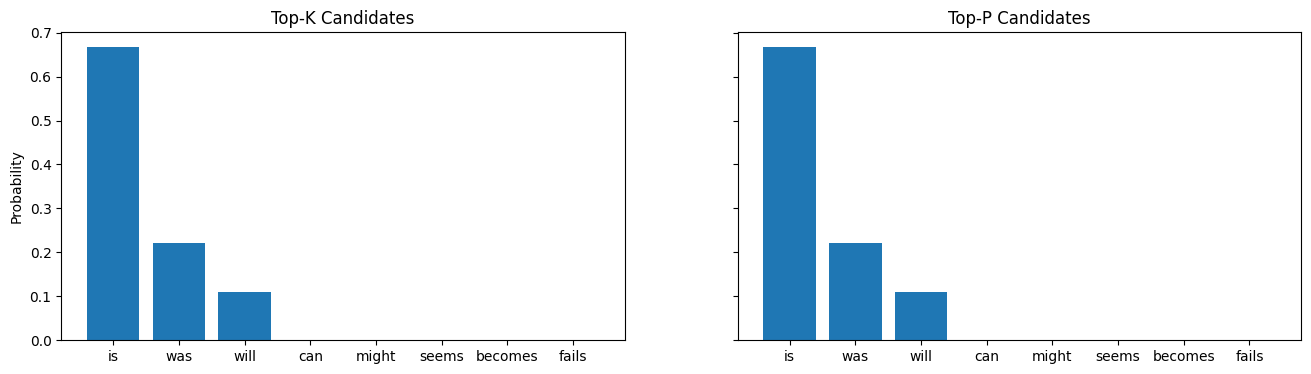

In [82]:
# ============================================================
#  Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

# --- Top-K ---
axes[0].bar(vocab, topk_probs)
axes[0].set_title("Top-K Candidates")
axes[0].set_ylabel("Probability")

# --- Top-P ---
axes[1].bar(vocab, topp_probs)
axes[1].set_title("Top-P Candidates")

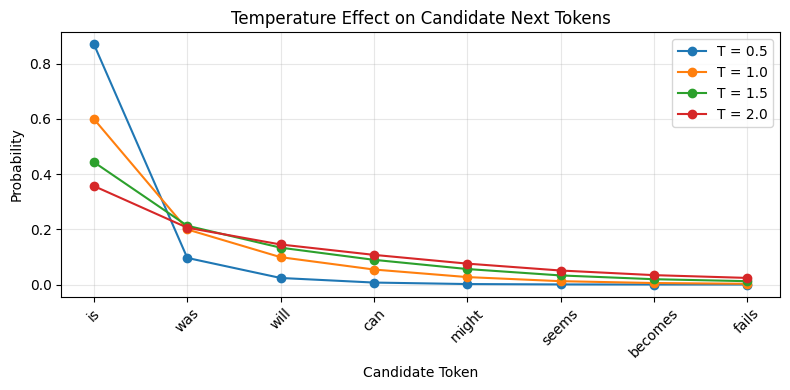

In [83]:
# -----------------------------
# Example logits and vocab
# -----------------------------
logits = torch.tensor([4.2, 3.1, 2.4, 1.8, 1.1, 0.3, -0.5, -1.2])
vocab = ["is", "was", "will", "can", "might", "seems", "becomes", "fails"]

# -----------------------------
# Temperature function
# -----------------------------
def apply_temperature(logits, temperature):
    temperature = max(1e-6, float(temperature))
    return logits / temperature

# -----------------------------
# Compute probabilities for different temperatures
# -----------------------------
temperatures = [0.5, 1.0, 1.5, 2.0]
temp_probs = {
    T: F.softmax(apply_temperature(logits, T), dim=-1)
    for T in temperatures
}

# -----------------------------
# CREATE FIGURE + AXES (CRITICAL)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(vocab))

# -----------------------------
# Plot temperature curves
# -----------------------------
for T, probs in temp_probs.items():
    ax.plot(x, probs.numpy(), marker="o", label=f"T = {T}")

# -----------------------------
# Axis formatting (NO WARNINGS)
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(vocab, rotation=45)
ax.set_ylabel("Probability")
ax.set_xlabel("Candidate Token")
ax.set_title("Temperature Effect on Candidate Next Tokens")
ax.legend()
ax.grid(True, alpha=0.3)

# -----------------------------
# SHOW (this must be last)
# -----------------------------
plt.tight_layout()
plt.show()

In [99]:
# Hugging Face GPT Model
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

In [100]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [101]:
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)

In [86]:
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)

In [102]:
sentence = "unsure" # un + sure
input_ids = tokenizer(sentence, return_tensors="pt")["input_ids"]
input_ids

tensor([[13271,   495]])

In [103]:
tokenizer.decode(input_ids[0])

'unsure'

In [106]:
tokenizer("unbeliavable", return_tensors="pt")["input_ids"]

tensor([[  403,  6667,   544, 23765]])

In [107]:
gpt2 = AutoModelForCausalLM.from_pretrained("gpt2")

In [108]:
gpt2

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [129]:
# sentence = "I like machine learning to be able to predict the future."
sentence = "I like to go shopping with my friends.I like to go shopping with my firends."
# Data Processing technique
token_ids = tokenizer(sentence, return_tensors="pt").input_ids

outputs = gpt2(token_ids).logits[0, -1]
tokenizer.decode(outputs.argmax()) # Greedy Search

'I'

In [146]:
def greedy_decode(logits):
    """Return token index with maximum probability."""
    return torch.argmax(logits, dim=-1)

# TOP K SAMPLING

def top_k_sampling(logits, k=50):
    """
    keeps only top-k logits, normalize them into probability.
    them sample one token from the filtered distribution.
    """
    values, indices = torch.topk(logits, k)
    probs = F.softmax(values, dim=-1)
    sampled = torch.multinomial(probs, 1)
    return indices[sampled]

# Top-p (Nuecles) Sampling

def top_p_sampling(logits, p=0.9):
    """
    Sort tokens by probability, keep smallest number whose culumative
    probability exceeds threshold p, then sample one token.
    """

    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumulative_probs = sorted_probs.cumsum(dim=-1)

    # Mask token outside nuclues
    mask = cumulative_probs > p
    sorted_logits[mask] = float("-inf")

    # Sample from filtered logits
    filtered_probs = F.softmax(sorted_logits, dim=-1)
    sampled = torch.multinomial(filtered_probs, 1)

    # Return token index in originial vocabulary
    return sorted_indices[sampled]

## Temperature Sampling ##

def temperature_sampling(logits, temperature=1.0):
    """
    Scale logits by temperature before sampling.
    Lower temperature => sharper distribution
    """

    scaled = logits / temperature
    probs = F.softmax(scaled, dim=-1)
    return torch.multinomial(probs, 1)


## Random Sampling ##

def random_sampling(logits):
    """
    Sample dirctly from softmax distribution without filtring
    """

    probs = F.softmax(logits, dim=-1)
    return torch.multinomial(probs, 1)

# sentence = "Today I decided to go to the local library and find out what was in my wallet."
# sentence = "I am really happy becuase I have been able to get my work done."
sentence = "I went to the most beautiful school in the world, Switzerland. And I met my first prefessor"
inputs = tokenizer(sentence, return_tensors="pt")
output = gpt2(**inputs)
logits = output.logits[0, -1]

print(f"Greedy Decode: ", tokenizer.decode([greedy_decode(logits)]))
print(f"Top-K Sampling: ", tokenizer.decode(top_k_sampling(logits, k=10)))
# print(f"Top-P-Sampling: ", tokenizer.decode(top_p_sampling(logits, p=0.9)))
print(f"Temp: ", tokenizer.decode(temperature_sampling(logits, temperature=1)))
print(f"Radnom: ", tokenizer.decode(random_sampling(logits)))

Greedy Decode:  ,
Top-K Sampling:   who
Temp:   and
Radnom:  ,
